# PCA of SST anomalies


In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import sys
import os
import seaborn as sns
import intake
from xeofs.single import EOF 
import xeofs as xe
from scipy.stats import linregress
from scipy import stats
from dask import delayed
from IPython.display import display, HTML
import imageio
#from joblib import Parallel, delayed
import matplotlib.dates as mdates
import intake
#from DV8_ext_opening import *
from DV8_extremes import *
#DV8_functions(1) packages
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.animation import FFMpegWriter
from matplotlib import animation, rc
from IPython.display import HTML
#my functions:


import matplotlib.colors as mcolors

from tempfile import TemporaryDirectory
from getpass import getuser
from pathlib import Path
import dask
from dask.distributed import Client, LocalCluster
import bokeh
import subprocess
import re

import warnings
#warnings.filterwarnings('ignore')
scratch_dir = Path('/scratch') / getuser()[0] / getuser()

/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:


dask.config.config.get('distributed').get('dashboard').update({'link':'{JUPYTERHUB_SERVICE_PREFIX}/proxy/{port}/status'})
cluster = LocalCluster(n_workers=32,threads_per_worker=1)
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/b382616/levante-spawner-advanced//proxy/8787/status,
Dashboard: /user/b382616/levante-spawner-advanced//proxy/8787/status,Workers: 32
Total threads: 32,Total memory: 250.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34413,Workers: 0
Dashboard: /user/b382616/levante-spawner-advanced//proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:37107,Total threads: 1
Dashboard: /user/b382616/levante-spawner-advanced//proxy/38629/status,Memory: 7.81 GiB
Nanny: tcp://127.0.0.1:37375,


# LOAD DATA
### Only take latitudes between 50°S and 70°N, to retain only ice-free oceans. To make sure no sea ice appears in these latitudes we apply SSTA=SSTA.where(sst>-1.7) for all anomalies. Gridcells with sea ice are defined in OSTIA,ICON and IFS-FESOM as an SST value of ~-1.75, by applying the where condition we make sure to only take ice free times and grid-cells without throwing out entire areas, but only the times and places where sea ice appears.
### Convert ICON and IFS-FESOM longitudes from 0->360 to -180->180

In [3]:

def lon_180w_180e(ds_sice: xr.DataArray):
    ds_sice = (
        ds_sice
        .assign_coords(lon=lambda x: (x.lon - 180) % 360 - 180)
        .sortby('lon'))

    return ds_sice

In [4]:
#SST

 # OSTIA
filename='/scratch/b/b382615/mhws/ostia.zarr' 
sst = xr.open_zarr(str(filename), chunks={'time':150, 'lat':-1, 'lon':-1}).sst
sst=sst.sel(lat=slice(-50, 70))
sst=sst-273.15

# ICON HISTORICAL
cat = intake.open_catalog("https://raw.githubusercontent.com/eerie-project/intake_catalogues/main/eerie.yaml")
dat = cat['dkrz.disk.model-output.icon-esm-er.hist-1950.v20240618.ocean.gr025']
sst_ic = dat['2d_daily_mean'](chunks={}).to_dask().to.isel(depth=0).drop_vars('depth').chunk({'time':150, 'lat':-1, 'lon':-1})
sst_ic=sst_ic.sel(lat=slice(-50, 70))


# IFS FESOM
cat = intake.open_catalog("https://raw.githubusercontent.com/eerie-project/intake_catalogues/main/eerie.yaml")
dat = cat['dkrz.disk.model-output.ifs-fesom2-sr.hist-1950.v20240304.ocean.gr025']#.icon-esm-er.hist-1950.v20240618.ocean.gr025']
sst_f = dat['2D_daily_avg_1950-2014'].to_dask().avg_tos.isel(depth=0).drop_vars('depth').chunk({'time':150, 'lat':-1, 'lon':-1})
sst_f=sst_f.sel(lat=slice(-50, 70))



In [6]:
# HADGEM LL
sst_LL = xr.open_dataset(
    '/home/b/b382616/scratch/mhws/hadgem/input_data/LL/toscon_nemo_u-da156_1d_19700101-20150101_grid-025.nc',
    chunks={'time': 150, 'lat': -1, 'lon': -1}  # Chunk by year, full spatial dimensions
)
sst_LL=sst_LL['toscon'].sel(lat=slice(-50, 70))


# HADGEM MM
sst_MM = xr.open_dataset(
    '/home/b/b382616/scratch/mhws/hadgem/input_data/MM/toscon_nemo_u-dc396_1d_19700101-20150101_grid-025.nc',
    chunks={'time': 150, 'lat': -1, 'lon': -1}  # Chunk by year, full spatial dimensions
)
sst_MM=sst_MM['toscon'].sel(lat=slice(-50, 70))


# HADGEM HH
sst_HH = xr.open_dataset(
    '/home/b/b382616/scratch/mhws/hadgem/input_data/HH/toscon_nemo_u-di356_1d_19700101-20150101_grid-025.nc',
    chunks={'time': 150, 'lat': -1, 'lon': -1}  # Chunk by year, full spatial dimensions
)
sst_HH=sst_HH['toscon'].sel(lat=slice(-50, 70))

            

/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'toscon' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'toscon' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'toscon' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


In [7]:
# SST ANOMALIES
# FIXED BASELINES


# FIXED BASELINES

# OSTIA ANOMALIES
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'OSTIA_pre_1982_2014_FixedDetrend_hob_oct25.zarr'
chunks={'time': 400, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
ds = xr.open_zarr(str(file_name), chunks=chunks)
ds = ds.sel(lat=slice(-50, 70))
ossta=ds['dat_anomaly']
sst=sst.sel(time=slice((ossta.time[0].values),str(ossta.time[-1].values))) #making sure SST time matches SSTA time before masking the sea ice
ossta=ossta.where(sst>-1.7) #remove from anomalies places and times where there is sea ice

file_name = scratch_dir / "mhws" / "DV8"/ "OSTIA_track_1982_2014_FixedDetrend_mask70_onlyarea.zarr"
chunks={'time': 400, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
ds = xr.open_zarr(str(file_name), chunks=chunks)
oblobs = ds.sel(lat=slice(-50, 70))



# ICON HIST ANOMALIES
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'ICONhist_pre_1982_2014_FixedDetrend_hob_nov25.zarr'
chunks={'time': 150, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
i_ds = xr.open_zarr(str(file_name), chunks=chunks)
i_ds=lon_180w_180e(i_ds)
sst_ic=lon_180w_180e(sst_ic)
i_ds = i_ds.sel(lat=slice(-50, 70))
issta=i_ds['dat_anomaly']
sst_ic=sst_ic.sel(time=slice(str(issta.time[0].values),str(issta.time[-1].values)))
# Now apply the sea ice mask
issta = issta.where(sst_ic > -1.7)



# IFS-FESOM ANOMALIES
#file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'IfsFesom_pre_1982_2014_FixedDetrend_hob_nov25.zarr'
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'IfsFesom_pre_1982_2014_FixedDetrend_hob_dec25.zarr'
chunks={'time': 150, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
f_ds = xr.open_zarr(str(file_name), chunks=chunks)
f_ds=lon_180w_180e(f_ds)
sst_f=lon_180w_180e(sst_f)
f_ds = f_ds.sel(lat=slice(-50, 70))
fssta=f_ds['dat_anomaly']
sst_f=sst_f.sel(time=slice((fssta.time[0].values),str(fssta.time[-1].values)))
# Now apply the sea ice mask
fssta = fssta.where(sst_f > -1.7)






# HADGEM LL ANOMALIES
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'hadgem'/'marEx'/'LL'/'HadGEM3-LL_marEx_extremes_detrend_fixed_baseline_1982-2014.zarr'
chunks={'time': 150, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
LL_ds = xr.open_zarr(str(file_name), chunks=chunks)
LL_ds=lon_180w_180e(LL_ds)
sst_LL=lon_180w_180e(sst_LL)
LL_ds = LL_ds.sel(lat=slice(-50, 70))
LLssta=LL_ds['dat_anomaly']
sst_LL=sst_LL.sel(time=slice((LLssta.time[0].values),str(LLssta.time[-1].values)))
# Now apply the sea ice mask
LLssta = LLssta.where(sst_LL > -1.7)

# HADGEM MM ANOMALIES
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'hadgem'/'marEx'/'MM'/'HadGEM3-MM_marEx_extremes_detrend_fixed_baseline_1982-2014.zarr'
chunks={'time': 150, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
MM_ds = xr.open_zarr(str(file_name), chunks=chunks)
MM_ds=lon_180w_180e(MM_ds)
sst_MM=lon_180w_180e(sst_MM)
MM_ds = MM_ds.sel(lat=slice(-50, 70))
MMssta=MM_ds['dat_anomaly']
sst_MM=sst_MM.sel(time=slice((MMssta.time[0].values),str(MMssta.time[-1].values)))
# Now apply the sea ice mask
MMssta = MMssta.where(sst_MM > -1.7)


# HADGEM HH ANOMALIES
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'hadgem'/'marEx'/'HH'/'HadGEM3-HH_marEx_extremes_detrend_fixed_baseline_1982-2014.zarr'
chunks={'time': 150, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
HH_ds = xr.open_zarr(str(file_name), chunks=chunks)
HH_ds=lon_180w_180e(HH_ds)
sst_HH=lon_180w_180e(sst_HH)
HH_ds = HH_ds.sel(lat=slice(-50, 70))
HHssta=HH_ds['dat_anomaly']
sst_HH=sst_HH.sel(time=slice((HHssta.time[0].values),str(HHssta.time[-1].values)))
# Now apply the sea ice mask
HHssta = HHssta.where(sst_HH> -1.7)



/tmp/ipykernel_2819395/1224992851.py:58: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 150. This could degrade performance. Instead, consider rechunking after loading.
  LL_ds = xr.open_zarr(str(file_name), chunks=chunks)
/tmp/ipykernel_2819395/1224992851.py:70: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 150. This could degrade performance. Instead, consider rechunking after loading.
  MM_ds = xr.open_zarr(str(file_name), chunks=chunks)
/tmp/ipykernel_2819395/1224992851.py:83: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 150. This could degrade performance. Instead, consider rechunking after loading.
  HH_ds = xr.open_zarr(str(file_name), chunks=chunks)


# PRE-PROCESSING
Before running PCA, you must weight your grid cells by the square root of the cosine of latitude. This is because grid cells near the poles are physically smaller than those at the equator; without weighting, the poles would have an outsized influence on your results.

In [8]:
models_dict = {
    'OSTIA': ossta,      # Your OSTIA extreme events data
    'ICON': issta,       # Your ICON extreme events data  
    'IFS-FESOM': fssta,   # Your IFS-FESOM extreme events data
    'HadGEM3-LL': LLssta,
    'HadGEM3-MM': MMssta,
    'HadGEM3-HH': HHssta
}

In [9]:

# Assuming 'models_list' is a list of your SSTA datasets
# e.g., models_dict = {'Model_A': ds1, 'Model_B': ds2}
results = {}

for name, ssta in models_dict.items():
    print(f"--- Processing {name} ---")
    
    # 1. Coarsen
    sub_small = ssta.coarsen(lat=4, lon=4, boundary="trim").mean()
    
    # 2. Create Mask
    mask = sub_small.notnull().all(dim='time').compute()
    
    # 3. Persist to RAM
    sub_ready = sub_small.where(mask).persist()
    
    # 4. Run EOF
    # solver='randomized' is often faster for large persistent arrays
    model = xe.single.EOF(n_modes=4, use_coslat=True)
    model.fit(sub_ready, dim="time")
    
    # 5. Store the model object (contains EOFs, PCs, and Exp Var)
    results[name] = {
        'model': model,
        'exp_var': model.explained_variance_ratio()
    }
    
    print(f"Done. Mode 1 for {name}: {results[name]['exp_var'][0].values*100:.2f}%")
    
    # 6. Cleanup to free RAM for the next model
    del sub_ready
    del sub_small

--- Processing OSTIA ---


/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/distributed/client.py:3374: UserWarning: Sending large graph of size 345.49 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/distributed/client.py:3374: UserWarning: Sending large graph of size 345.49 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/distributed/client.py:3374: UserWarning: Sending large 

Done. Mode 1 for OSTIA: 12.47%
--- Processing ICON ---


/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/distributed/client.py:3374: UserWarning: Sending large graph of size 334.64 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/distributed/client.py:3374: UserWarning: Sending large graph of size 334.64 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/distributed/client.py:3374: UserWarning: Sending large 

Done. Mode 1 for ICON: 6.44%
--- Processing IFS-FESOM ---


...

Done. Mode 1 for HadGEM3-LL: 25.40%
--- Processing HadGEM3-MM ---


2026-01-08 11:42:30,128 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 5.16 GiB -- Worker memory limit: 7.81 GiB
2026-01-08 11:45:51,081 - distributed.worker.memory - WARNING - Worker is at 82% memory usage. Pausing worker.  Process memory: 6.45 GiB -- Worker memory limit: 7.81 GiB
2026-01-08 11:45:51,576 - distributed.worker.memory - WARNING - Worker is at 77% memory usage. Resuming worker. Process memory: 6.07 GiB -- Worker memory limit: 7.81 GiB
2026-01-08 11:45:59,703 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memo

Done. Mode 1 for HadGEM3-MM: 16.04%
--- Processing HadGEM3-HH ---


2026-01-08 11:51:05,386 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 5.30 GiB -- Worker memory limit: 7.81 GiB
2026-01-08 11:52:01,567 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 5.69 GiB -- Worker memory limit: 7.81 GiB
/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/distributed/client.py:3374: UserWarning: Sending large graph of size 341.72 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the gra

Done. Mode 1 for HadGEM3-HH: 11.12%


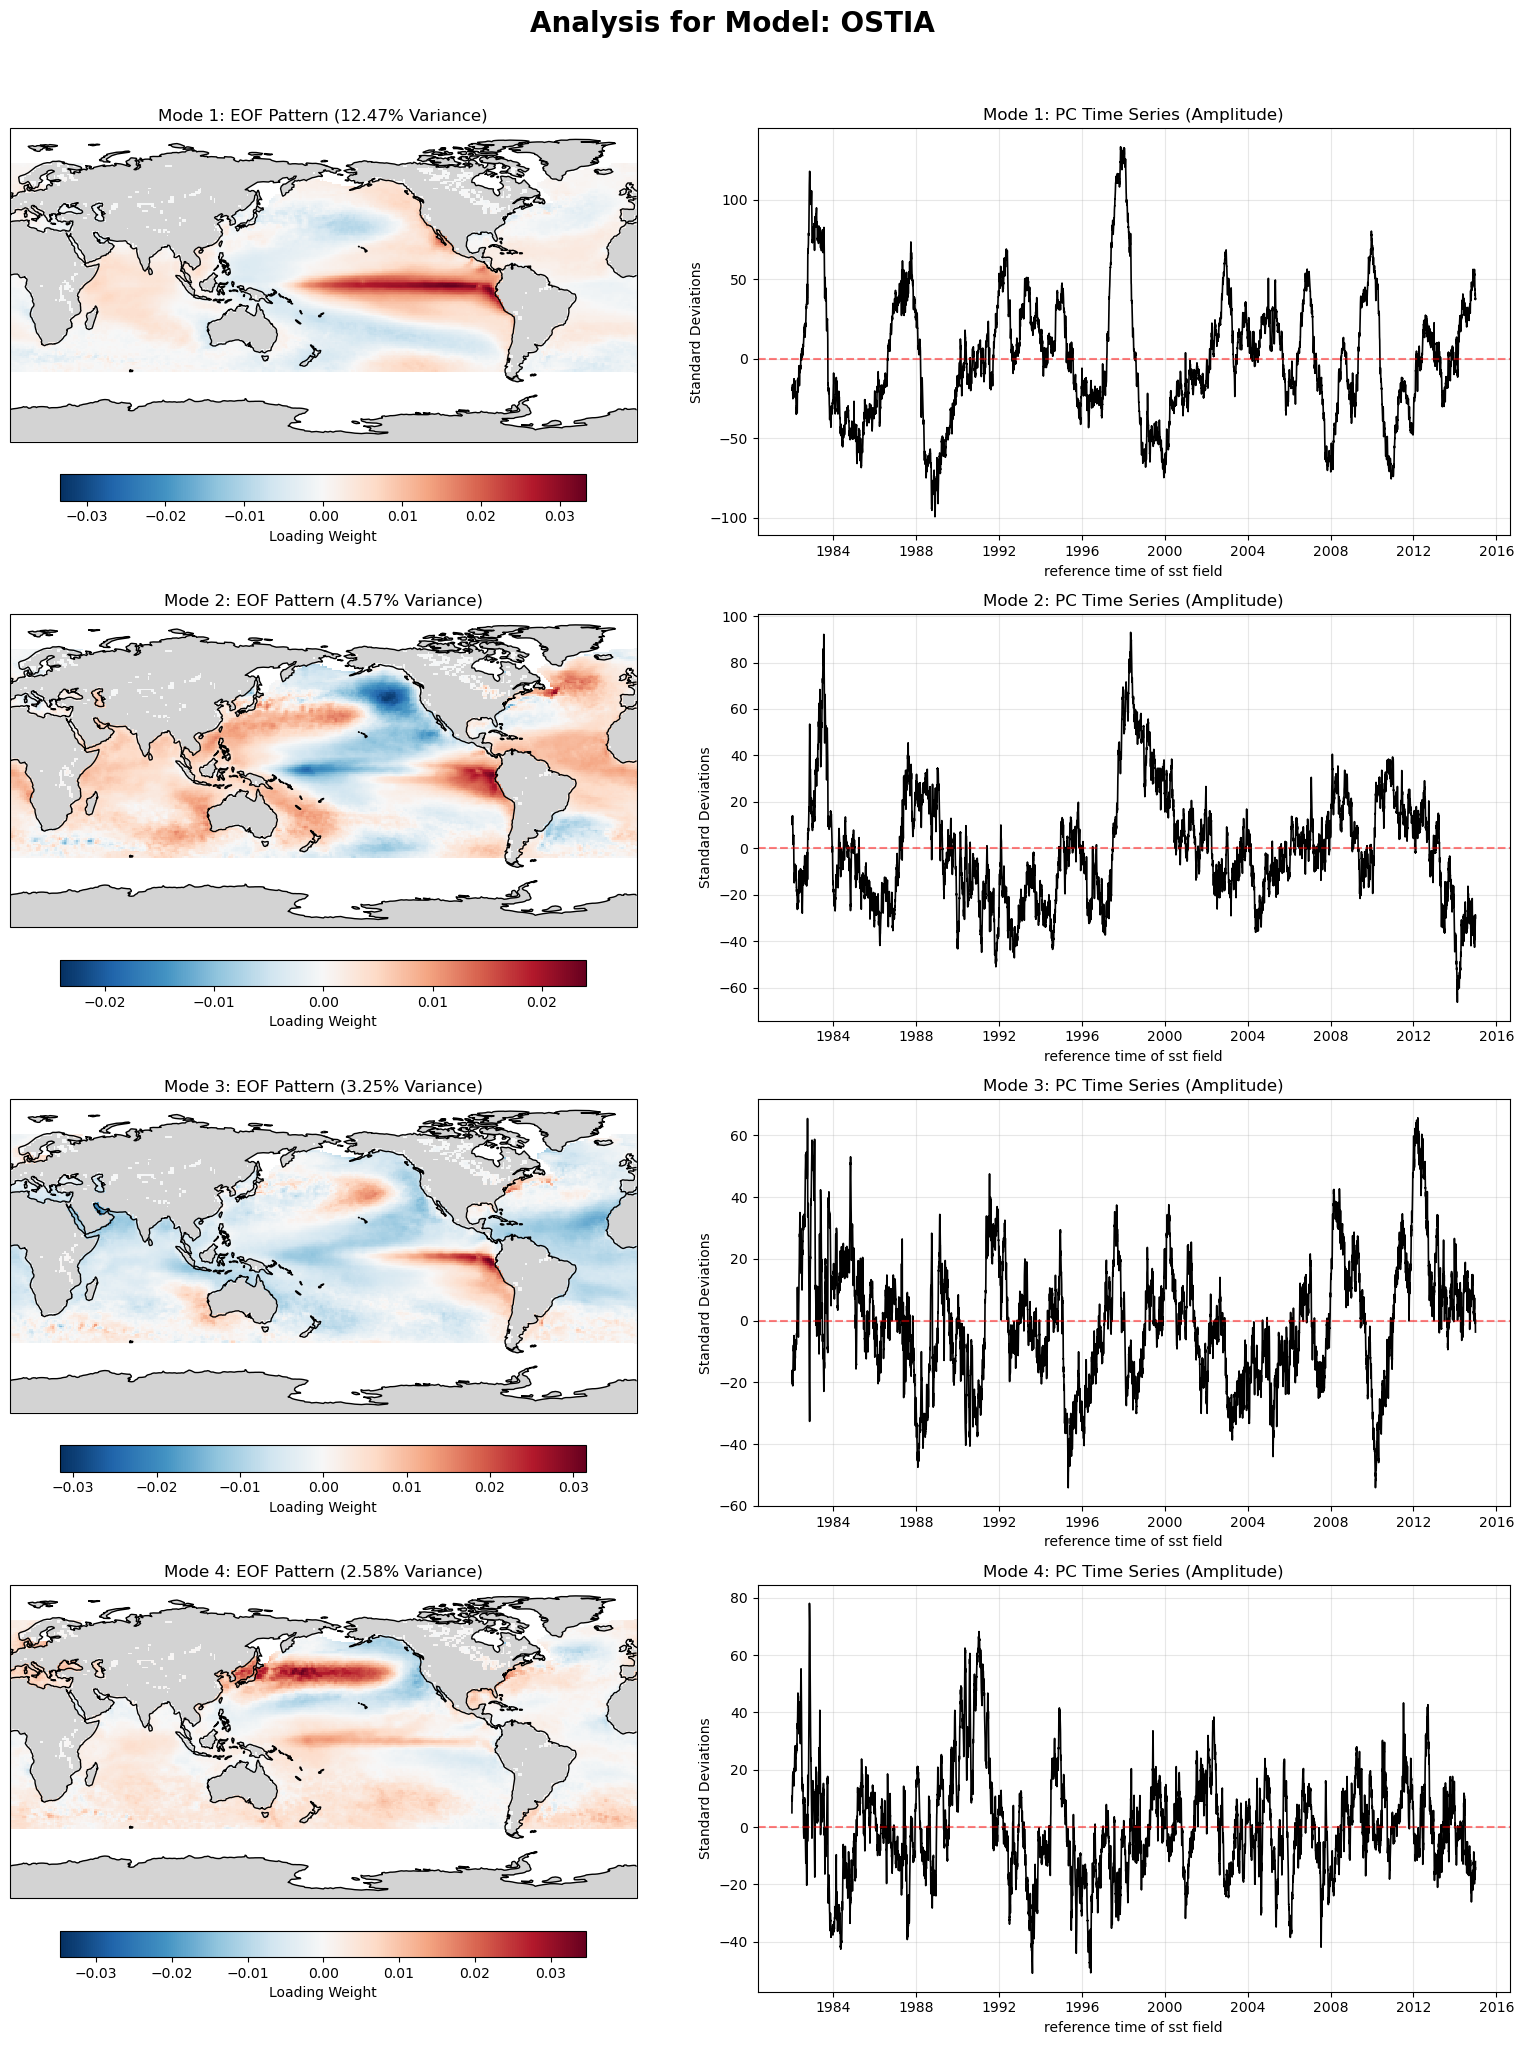

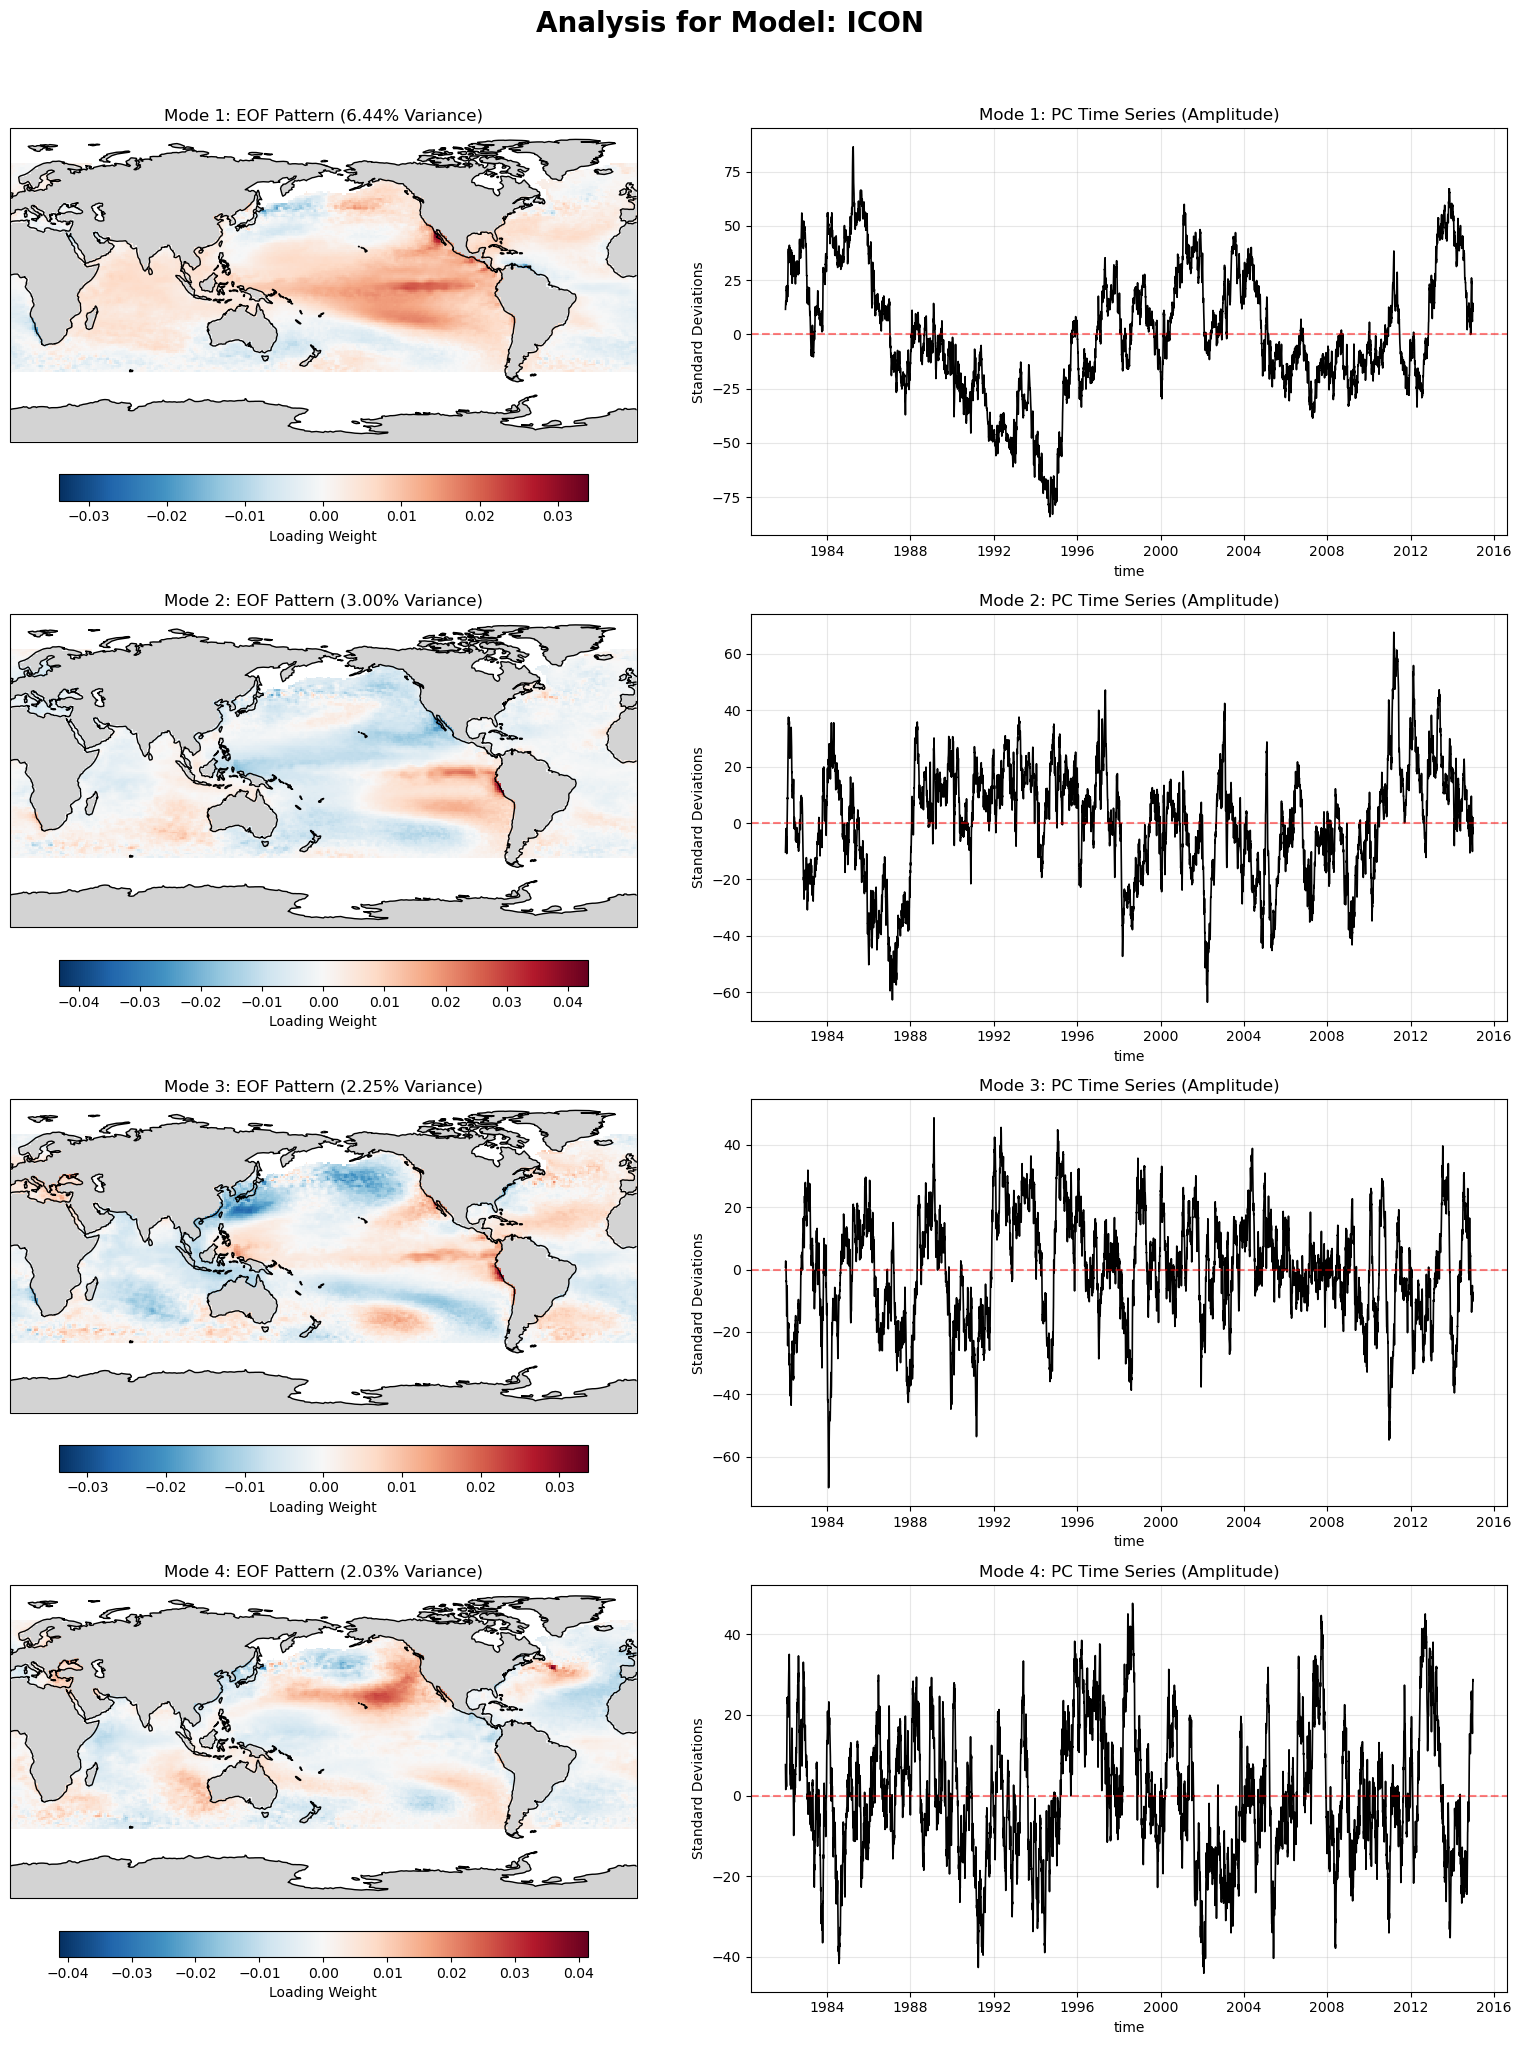

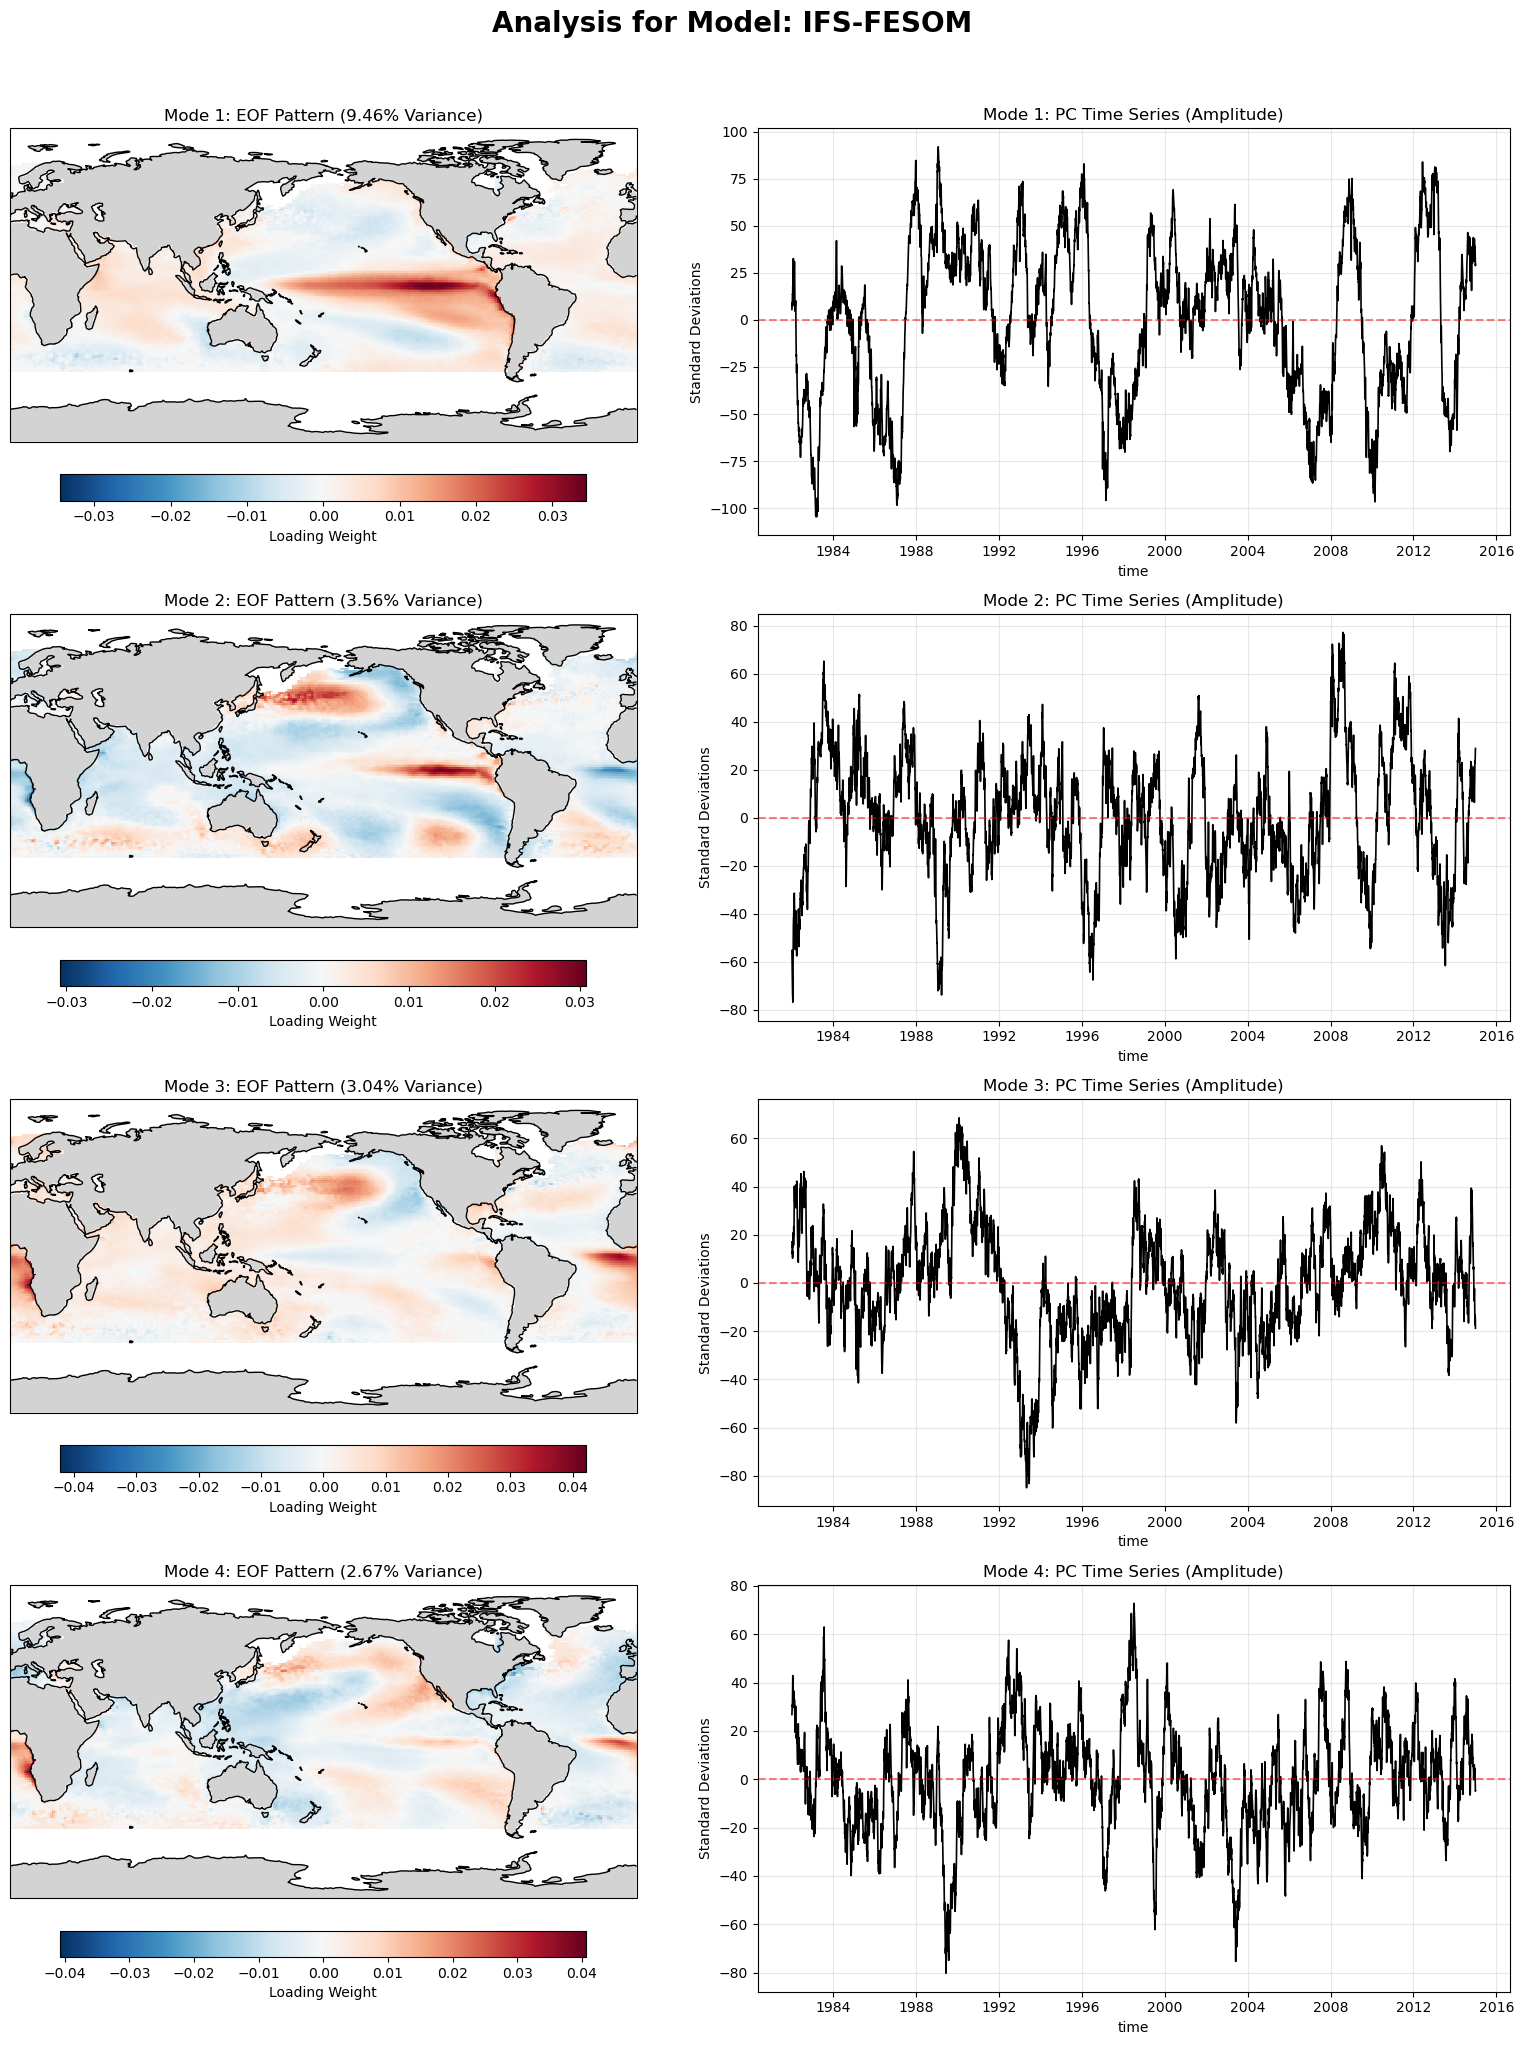

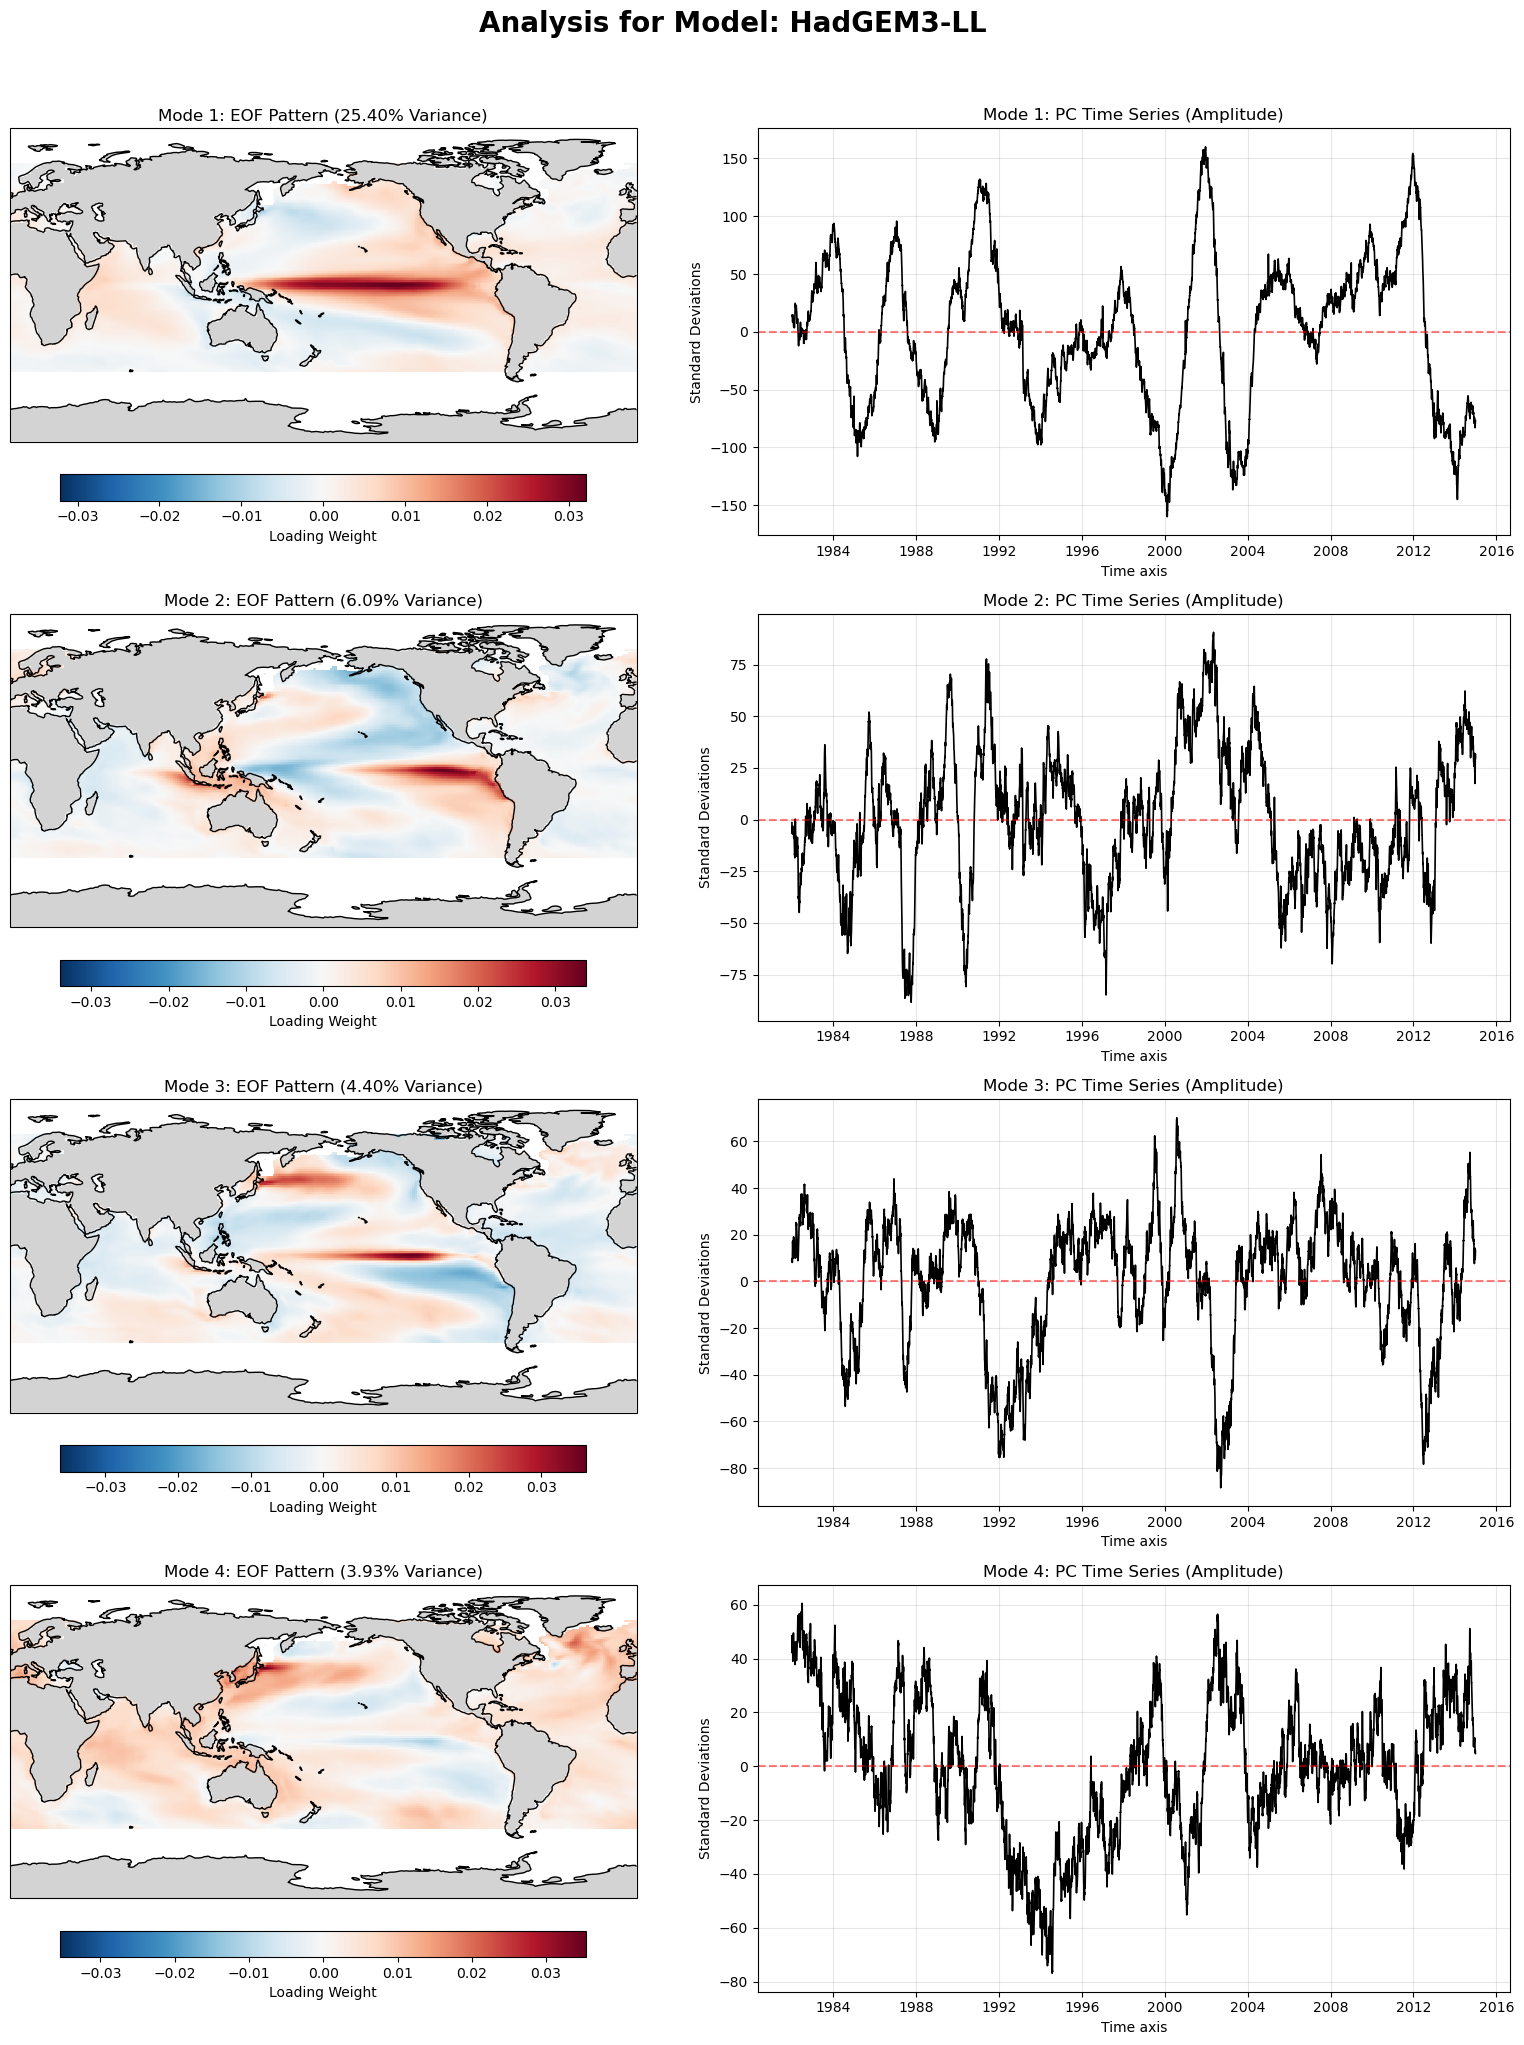

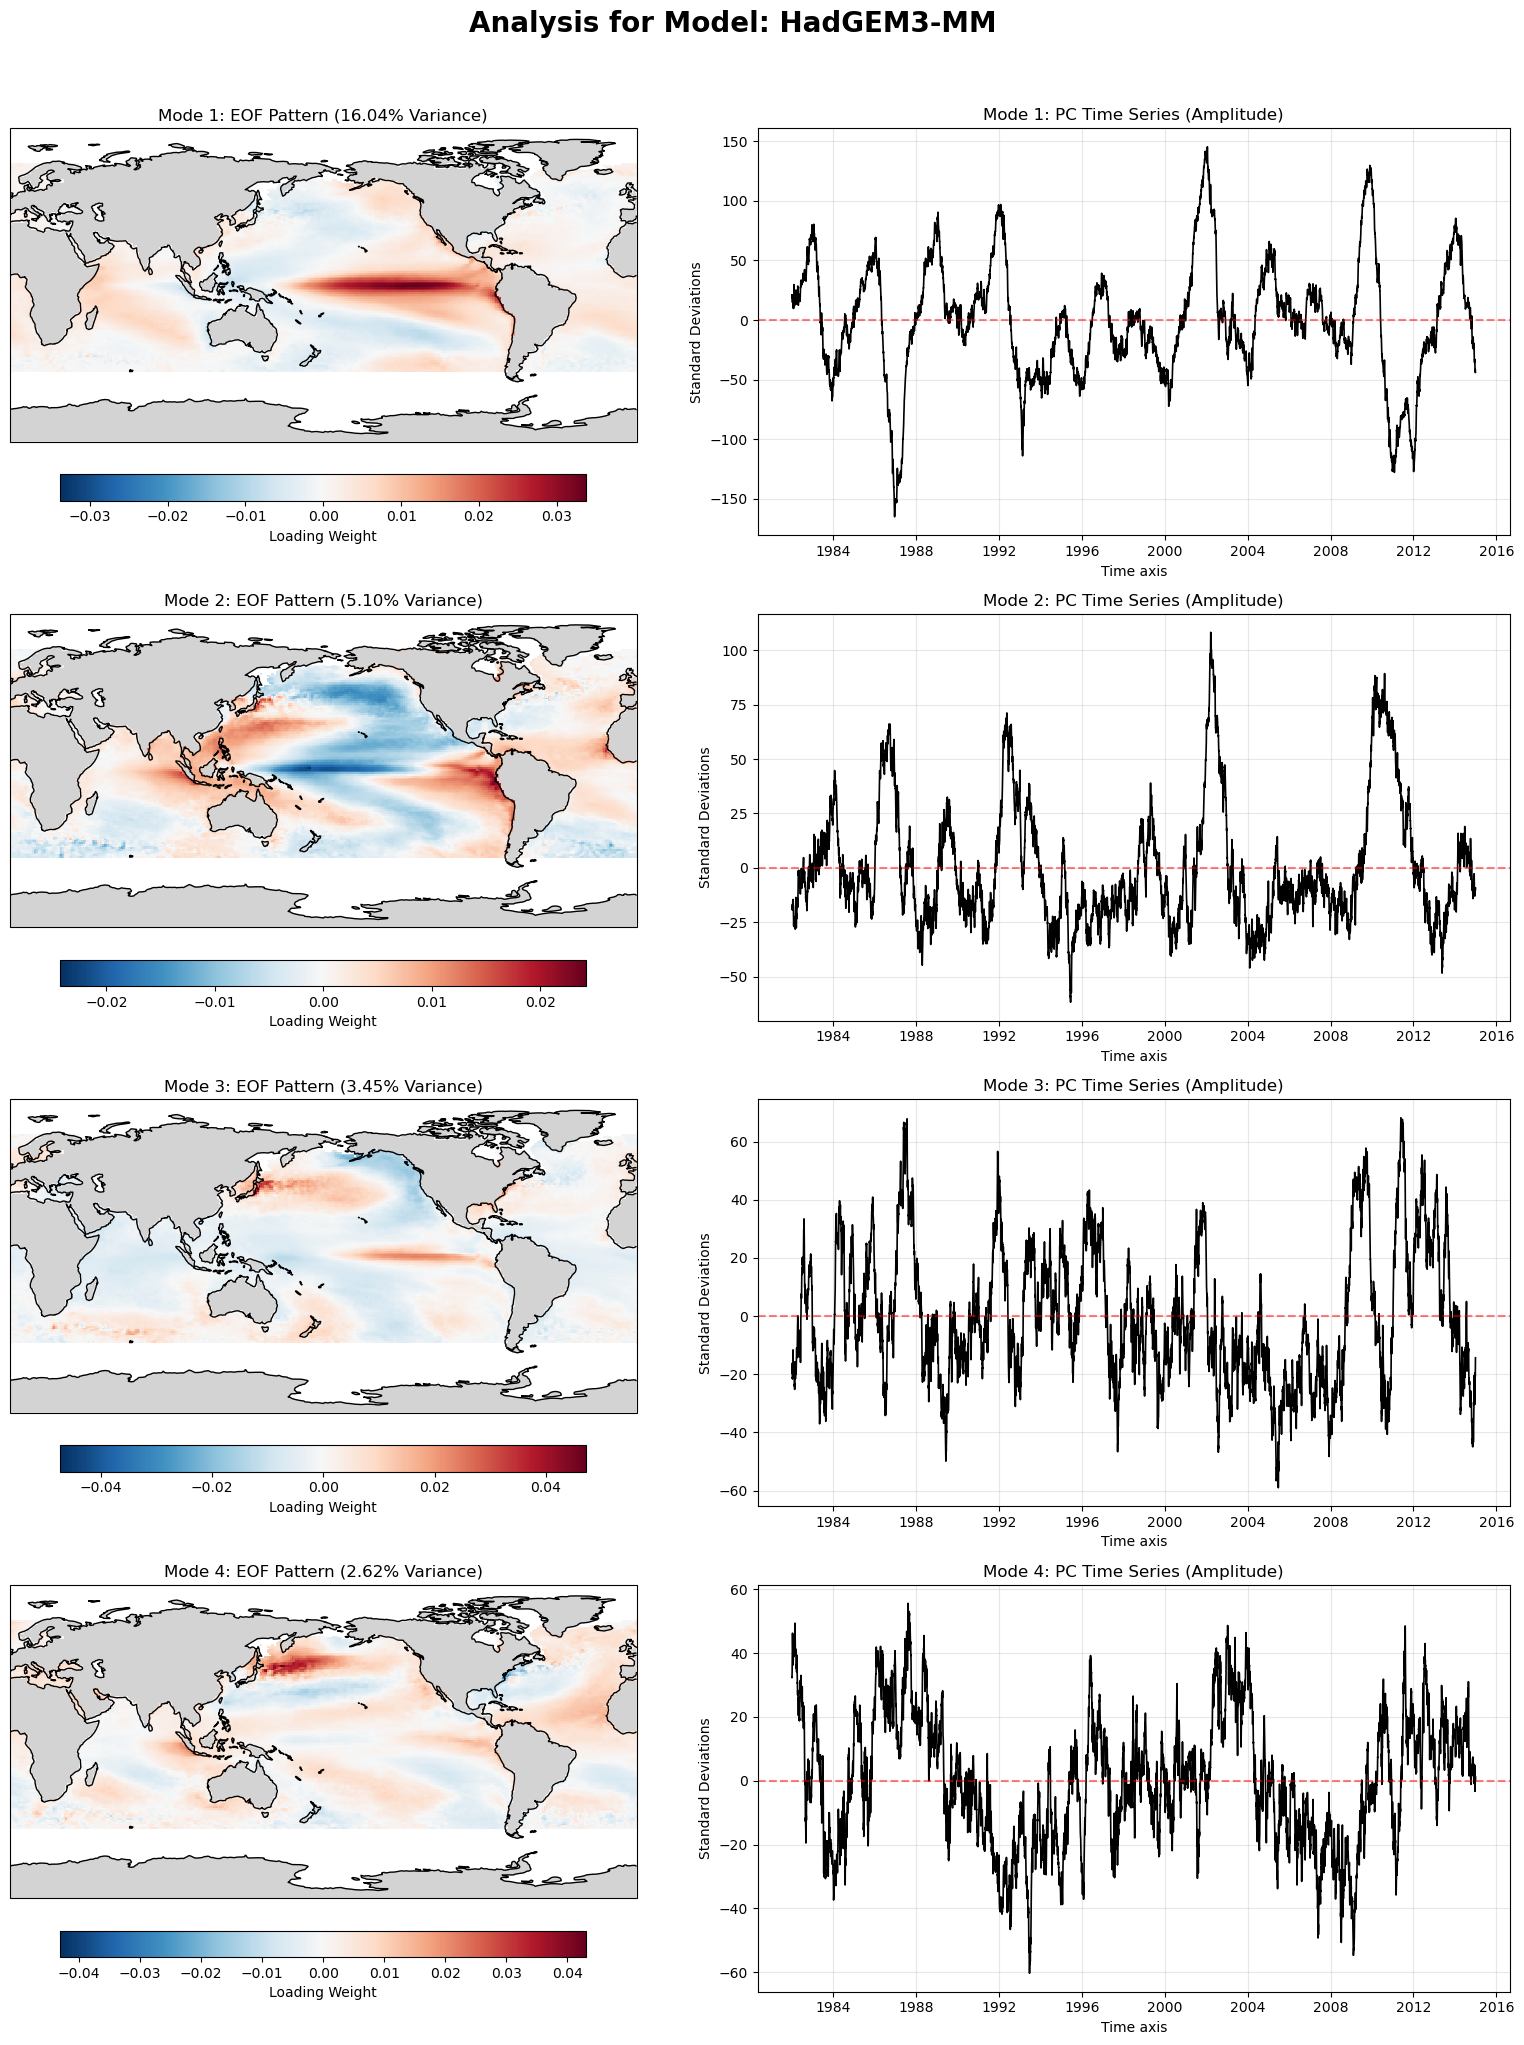

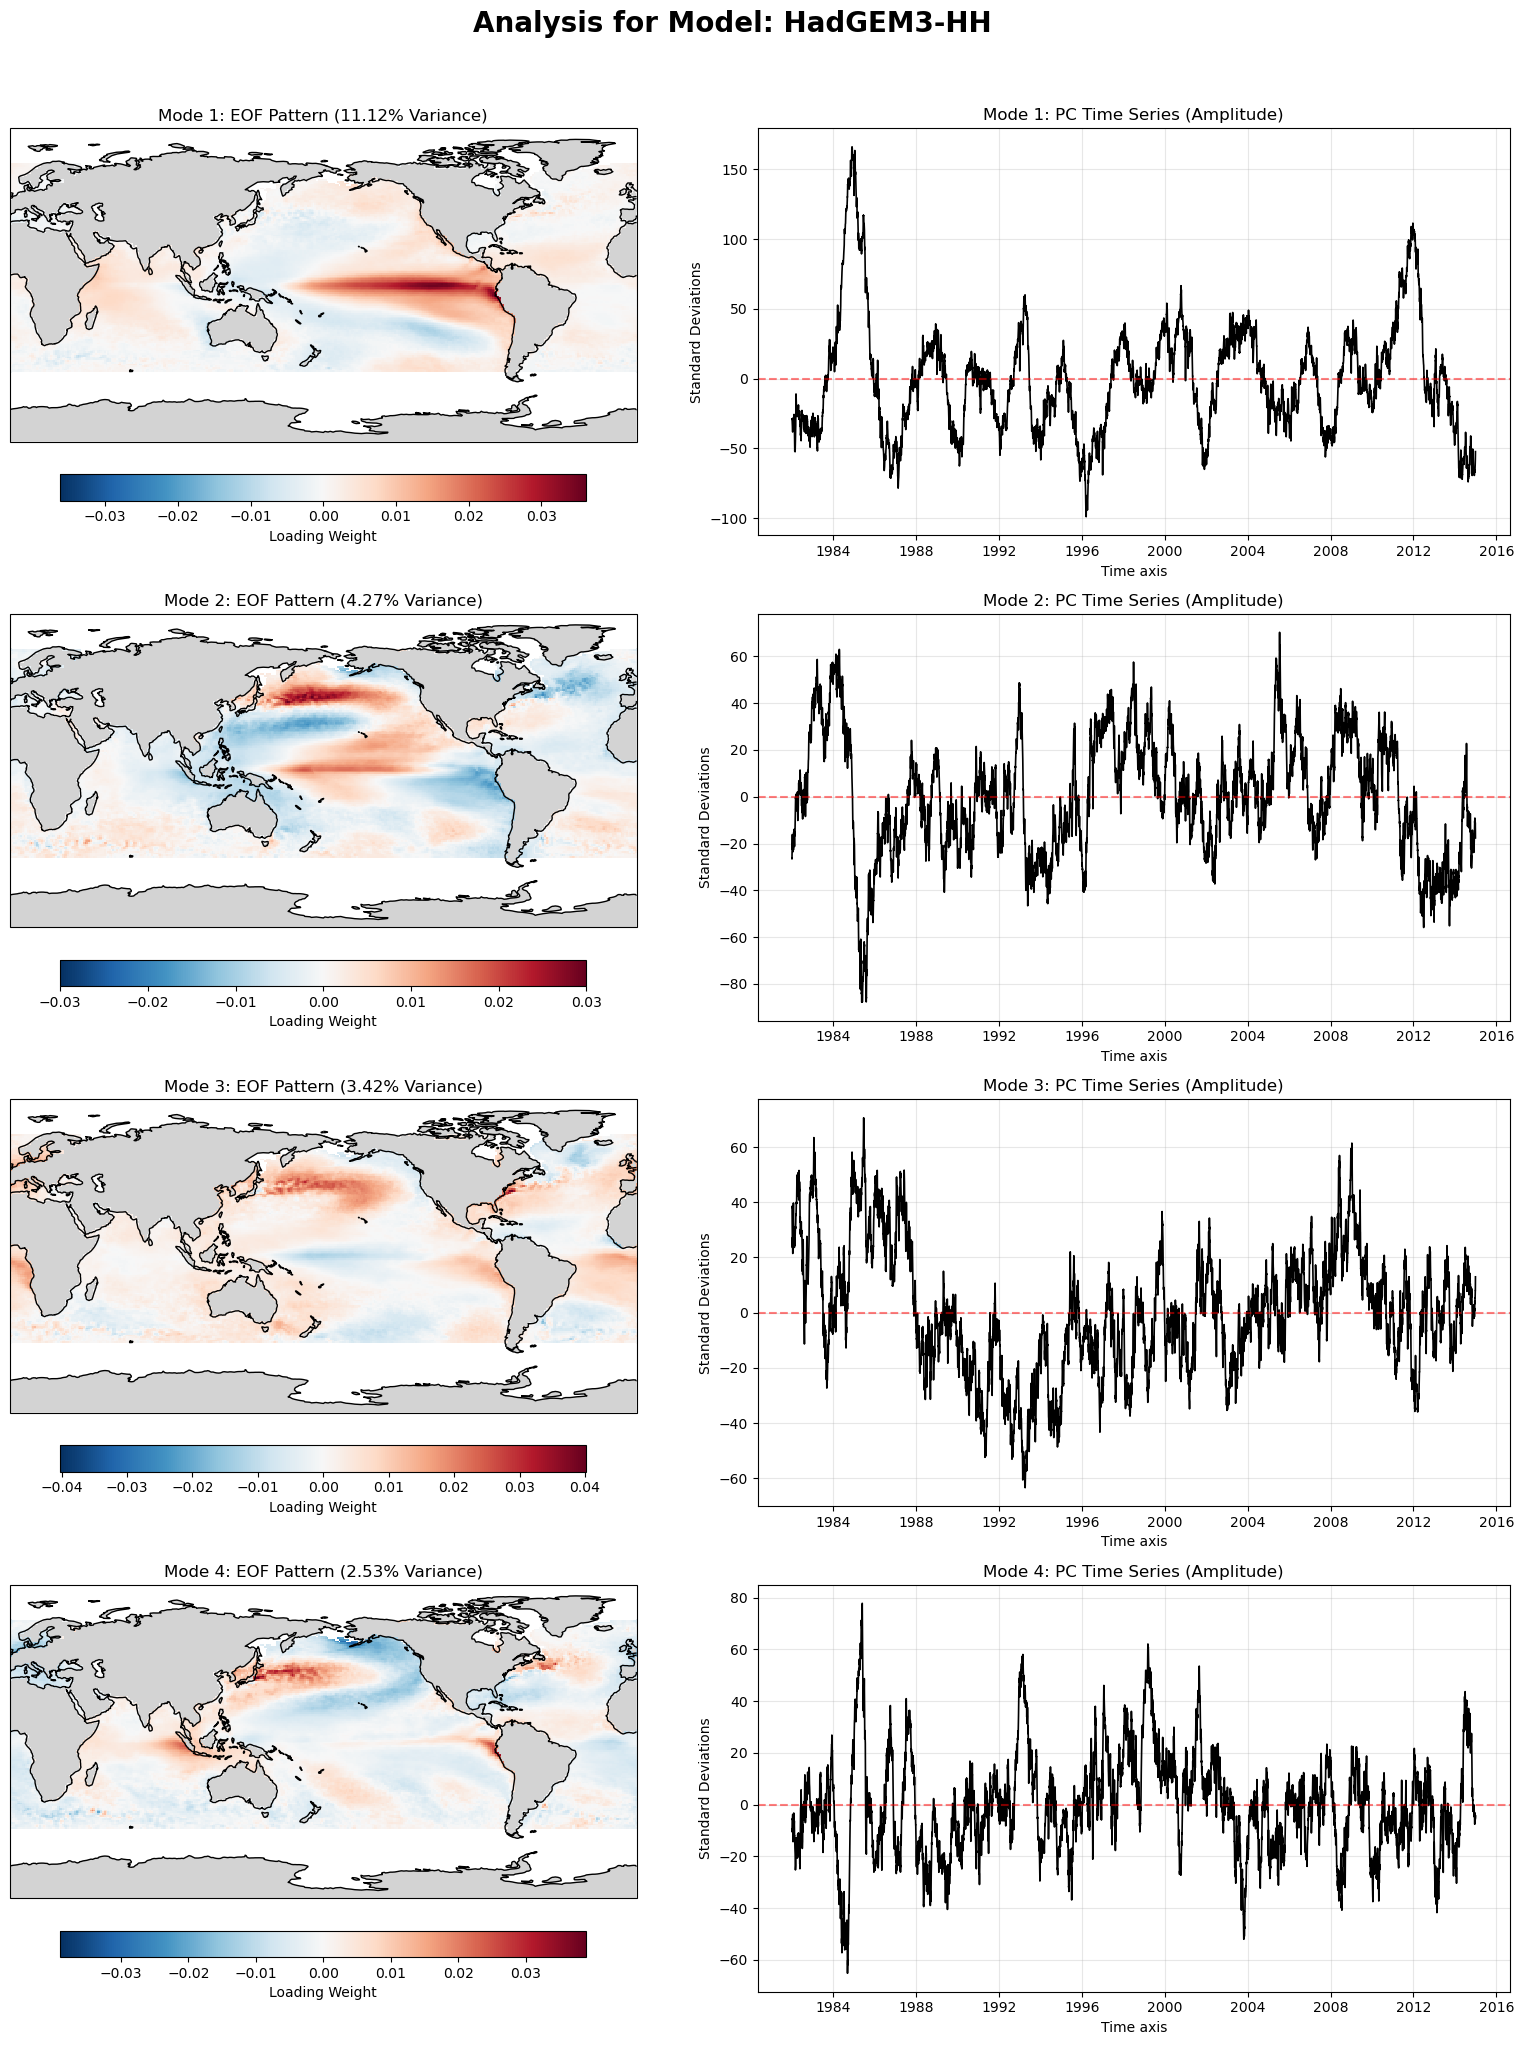

In [10]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cartopy.feature as cfeature

# Assuming 'results' is the dictionary from the previous step 
# containing {'model_name': {'model': model_obj, 'exp_var': ...}}

# Settings
n_modes = 4
map_proj = ccrs.PlateCarree(central_longitude=180)
data_trans = ccrs.PlateCarree()

for name, data in results.items():
    # Extract model and scores for this specific model
    model_obj = data['model']
    eofs = model_obj.components()
    pcs = model_obj.scores()
    exp_var_i = model_obj.explained_variance_ratio() * 100
    
    # Create a figure for this model
    fig = plt.figure(figsize=(16, 5 * n_modes))
    plt.suptitle(f"Analysis for Model: {name}", fontsize=20, fontweight='bold', y=1.02)

    for i in range(n_modes):
        mode_num = i + 1
        
        # --- EOF Map (Left Column) ---
        ax_map = fig.add_subplot(n_modes, 2, 2*i + 1, projection=map_proj)
        ax_map.set_global()
        
        # Determine consistent color limits for comparison (optional)
        # Using a fixed vmin/vmax helps compare patterns across models
        p = eofs.sel(mode=mode_num).plot(
            ax=ax_map, 
            transform=data_trans, 
            cmap='RdBu_r',
            add_colorbar=False
        )
        
        ax_map.coastlines()
        ax_map.add_feature(cfeature.LAND, facecolor='lightgray')
        plt.colorbar(p, ax=ax_map, orientation='horizontal', label='Loading Weight', pad=0.08, shrink=0.7)
        ax_map.set_title(f"Mode {mode_num}: EOF Pattern ({exp_var_i.values[i]:.2f}% Variance)")

        # --- PC Time Series (Right Column) ---
        ax_ts = fig.add_subplot(n_modes, 2, 2*i + 2)
        pcs.sel(mode=mode_num).plot(ax=ax_ts, color='black', lw=1.2)
        ax_ts.axhline(0, color='red', linestyle='--', alpha=0.5)
        ax_ts.set_title(f"Mode {mode_num}: PC Time Series (Amplitude)")
        ax_ts.set_ylabel("Standard Deviations")
        ax_ts.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [16]:
print("--- Explained Variance by Model ---")
for name, data in results.items():
    percentages = data['exp_var'] * 100
    # Create a string of percentages for the modes (n_modes=2)
    mode_str = ", ".join([f"Mode {i+1}: {val:.2f}%" for i, val in enumerate(percentages.values)])
    print(f"{name} -> {mode_str}")

--- Explained Variance by Model ---
OSTIA -> Mode 1: 12.47%, Mode 2: 4.57%
ICON -> Mode 1: 6.44%, Mode 2: 3.00%
IFS-FESOM -> Mode 1: 9.46%, Mode 2: 3.56%


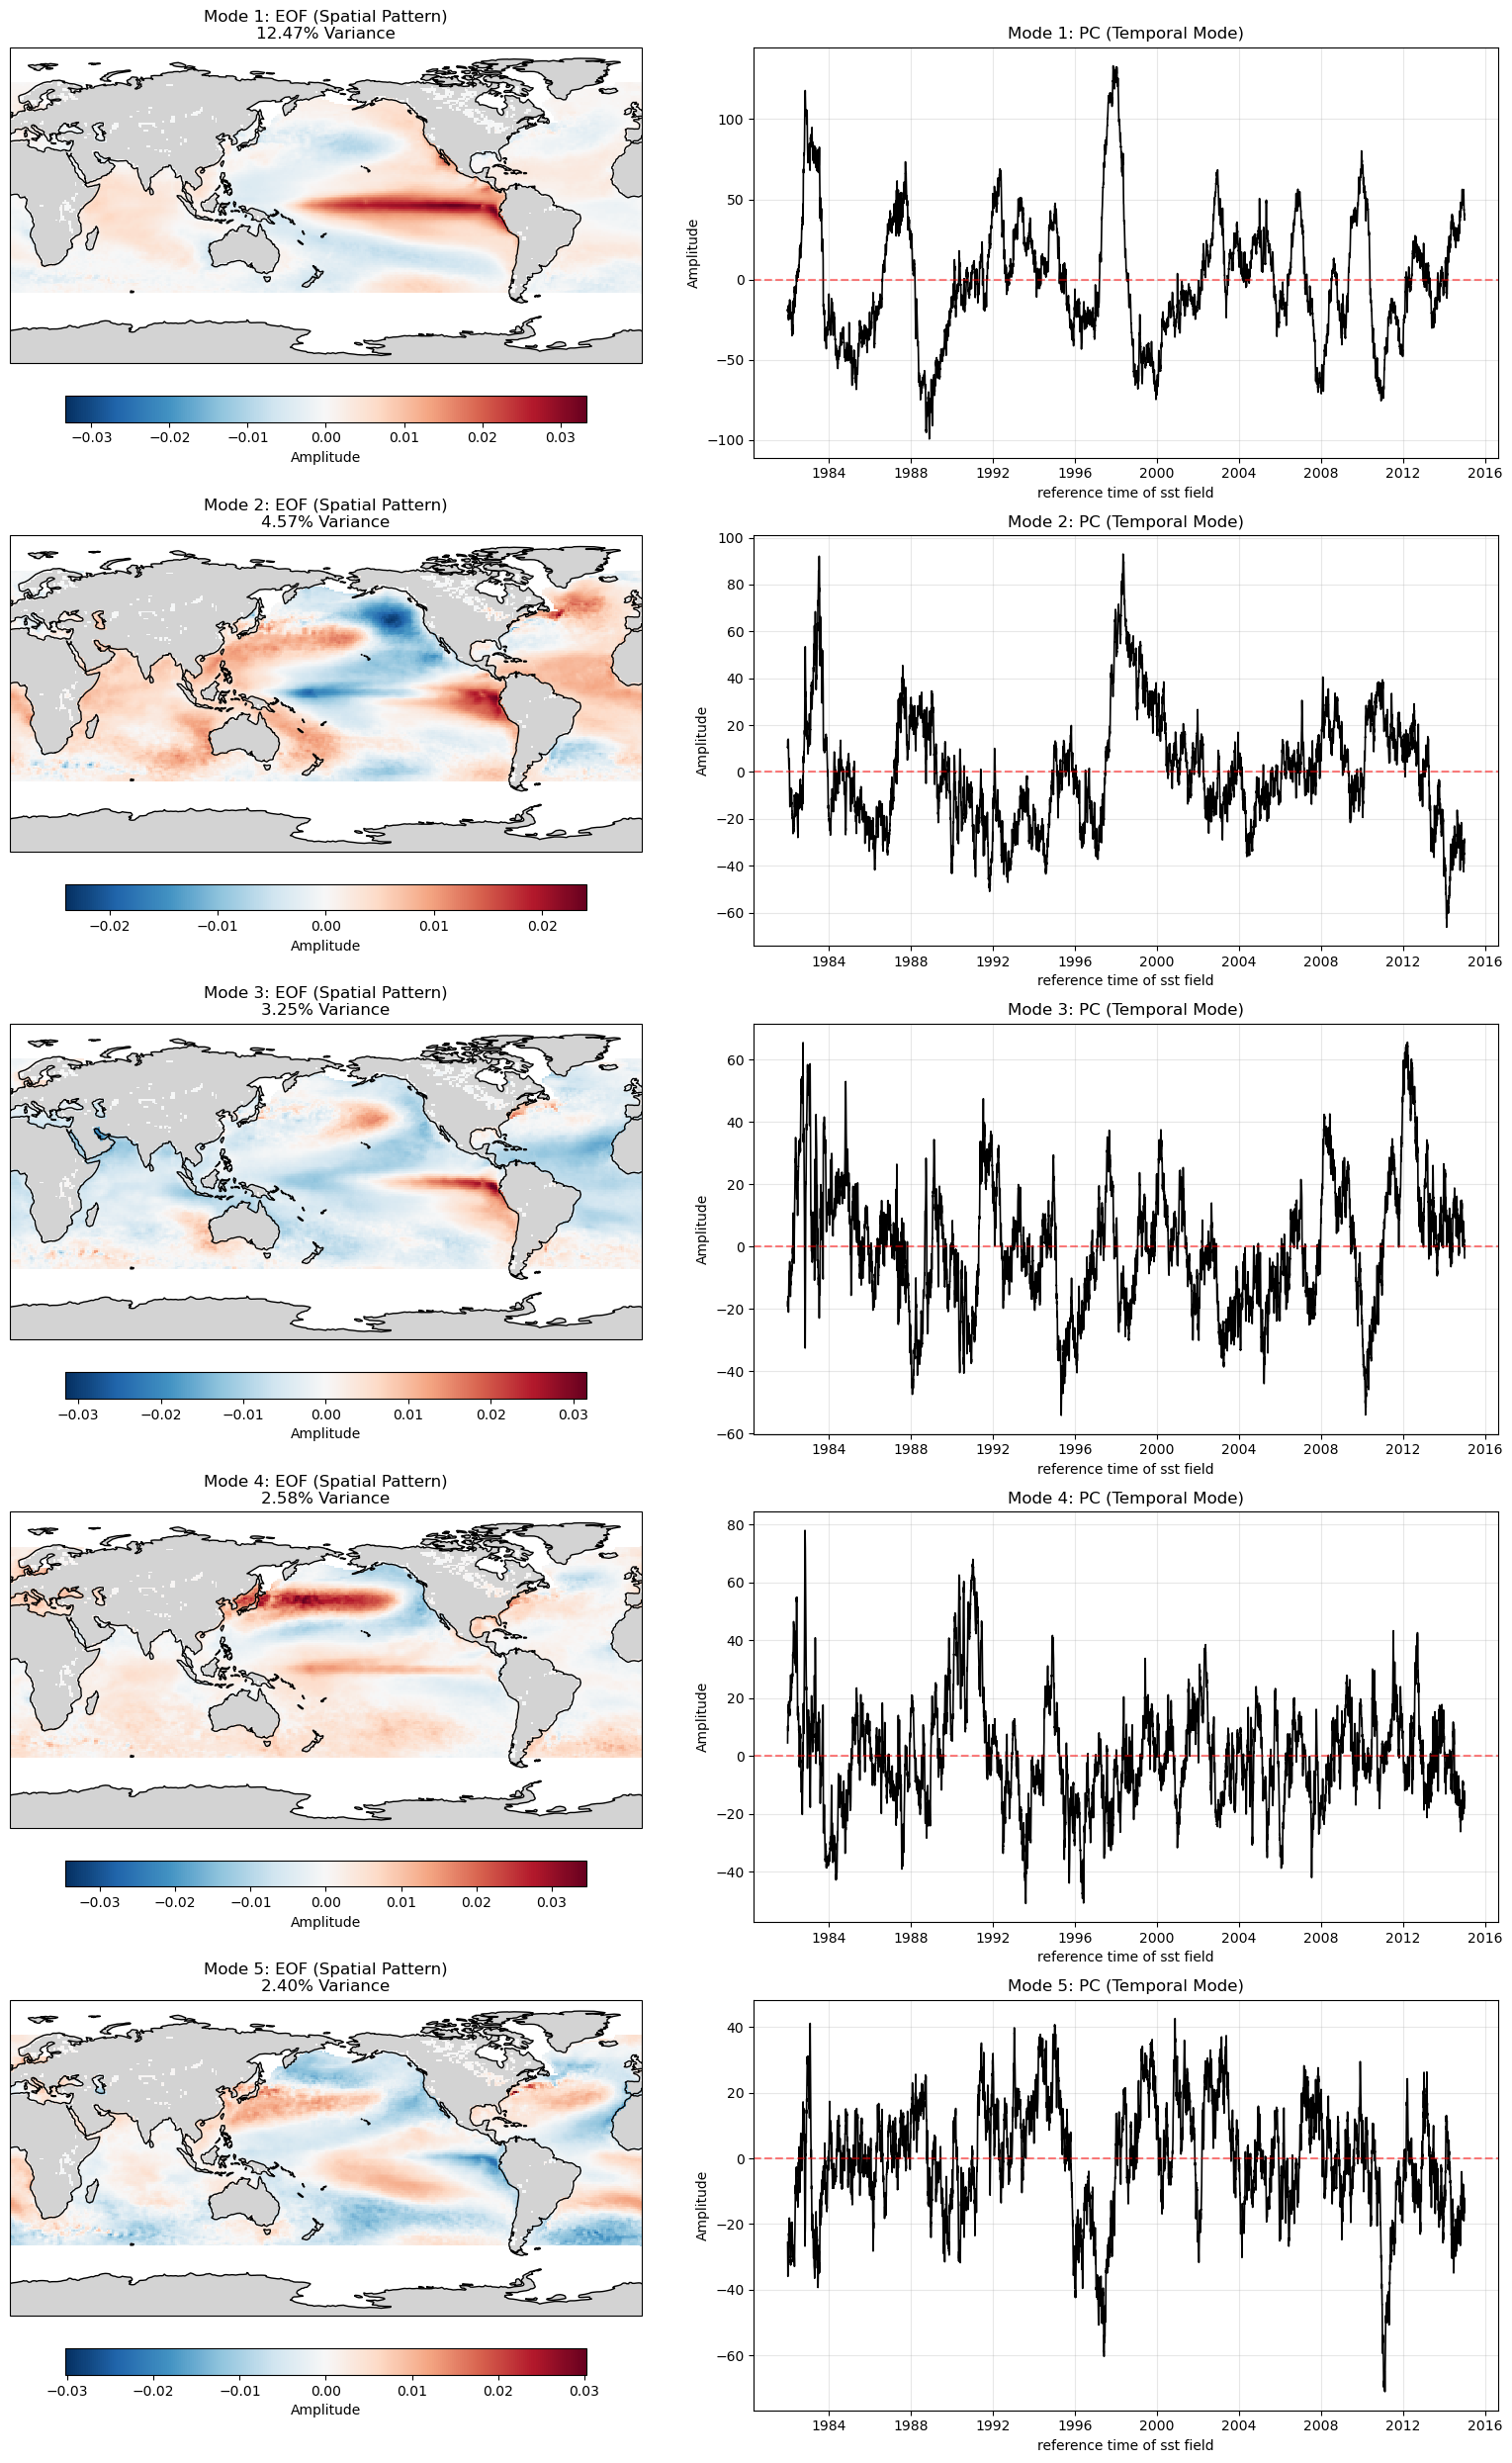

In [22]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cartopy.feature as cfeature

# 1. Get the results
eofs = model.components()
pcs = model.scores()
exp_var = model.explained_variance_ratio() * 100

# 2. Setup Figure
n_modes = 5
fig = plt.figure(figsize=(16, 5 * n_modes))

# Define the Pacific-centered projection
# 180 puts the International Date Line in the center
map_proj = ccrs.PlateCarree(central_longitude=180)
# Data transform stays as standard (0 central longitude)
data_trans = ccrs.PlateCarree()

for i in range(n_modes):
    mode_num = i + 1
    
    # --- EOF Map (Left Column) ---
    ax_map = fig.add_subplot(n_modes, 2, 2*i + 1, projection=map_proj)
    
    # Crucial: Force the map to show the whole world
    ax_map.set_global()
    
    # Plot data
    # transform=data_trans tells cartopy your lon/lat values are in standard coords
    p = eofs.sel(mode=mode_num).plot(
        ax=ax_map, 
        transform=data_trans, 
        cmap='RdBu_r',
        add_colorbar=False
    )
    
    # Add map features
    ax_map.coastlines()
    ax_map.add_feature(cfeature.LAND, facecolor='lightgray')
    
    # Add a horizontal colorbar below the map
    plt.colorbar(p, ax=ax_map, orientation='horizontal', label='Amplitude', pad=0.08, shrink=0.7)
    
    ax_map.set_title(f"Mode {mode_num}: EOF (Spatial Pattern)\n{exp_var.values[i]:.2f}% Variance")

    # --- PC Time Series (Right Column) ---
    ax_ts = fig.add_subplot(n_modes, 2, 2*i + 2)
    pcs.sel(mode=mode_num).plot(ax=ax_ts, color='black', lw=1.2)
    ax_ts.axhline(0, color='red', linestyle='--', alpha=0.5)
    ax_ts.set_title(f"Mode {mode_num}: PC (Temporal Mode)")
    ax_ts.set_ylabel("Amplitude")
    ax_ts.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ICON

In [23]:
sub= issta
# 1. Coarsen for speed
sub_small = sub.coarsen(lat=4, lon=4, boundary="trim").mean()

# 2. Identify stable ocean points and load the mask into RAM (it's small)
mask = sub_small.notnull().all(dim='time').compute()

# 3. Apply mask and "Persist" the data to your 250GB RAM
# This tells Dask to actually calculate the values and keep them in memory
# so the PCA doesn't have to read from disk over and over.
sub_ready = sub_small.where(mask).persist()
# Initialize with randomized solver for large matrices
model = xe.single.EOF(n_modes=5, use_coslat=True)

# This should now be much faster because 'sub_ready' is already in RAM
model.fit(sub_ready, dim="time")

exp_var_i = model.explained_variance_ratio()
print(exp_var)

/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/distributed/client.py:3374: UserWarning: Sending large graph of size 334.64 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/distributed/client.py:3374: UserWarning: Sending large graph of size 334.64 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/distributed/client.py:3374: UserWarning: Sending large 

<xarray.DataArray 'explained_variance_ratio' (mode: 5)> Size: 40B
array([12.47255176,  4.57055181,  3.25082918,  2.58359246,  2.40419526])
Coordinates:
  * mode     (mode) int64 40B 1 2 3 4 5
Attributes: (12/15)
    model:          EOF analysis
    software:       xeofs
    version:        3.0.4
    date:           2026-01-07 15:32:23
    n_modes:        5
    center:         True
    ...             ...
    sample_name:    sample
    feature_name:   feature
    random_state:   None
    compute:        True
    solver:         auto
    solver_kwargs:  {}


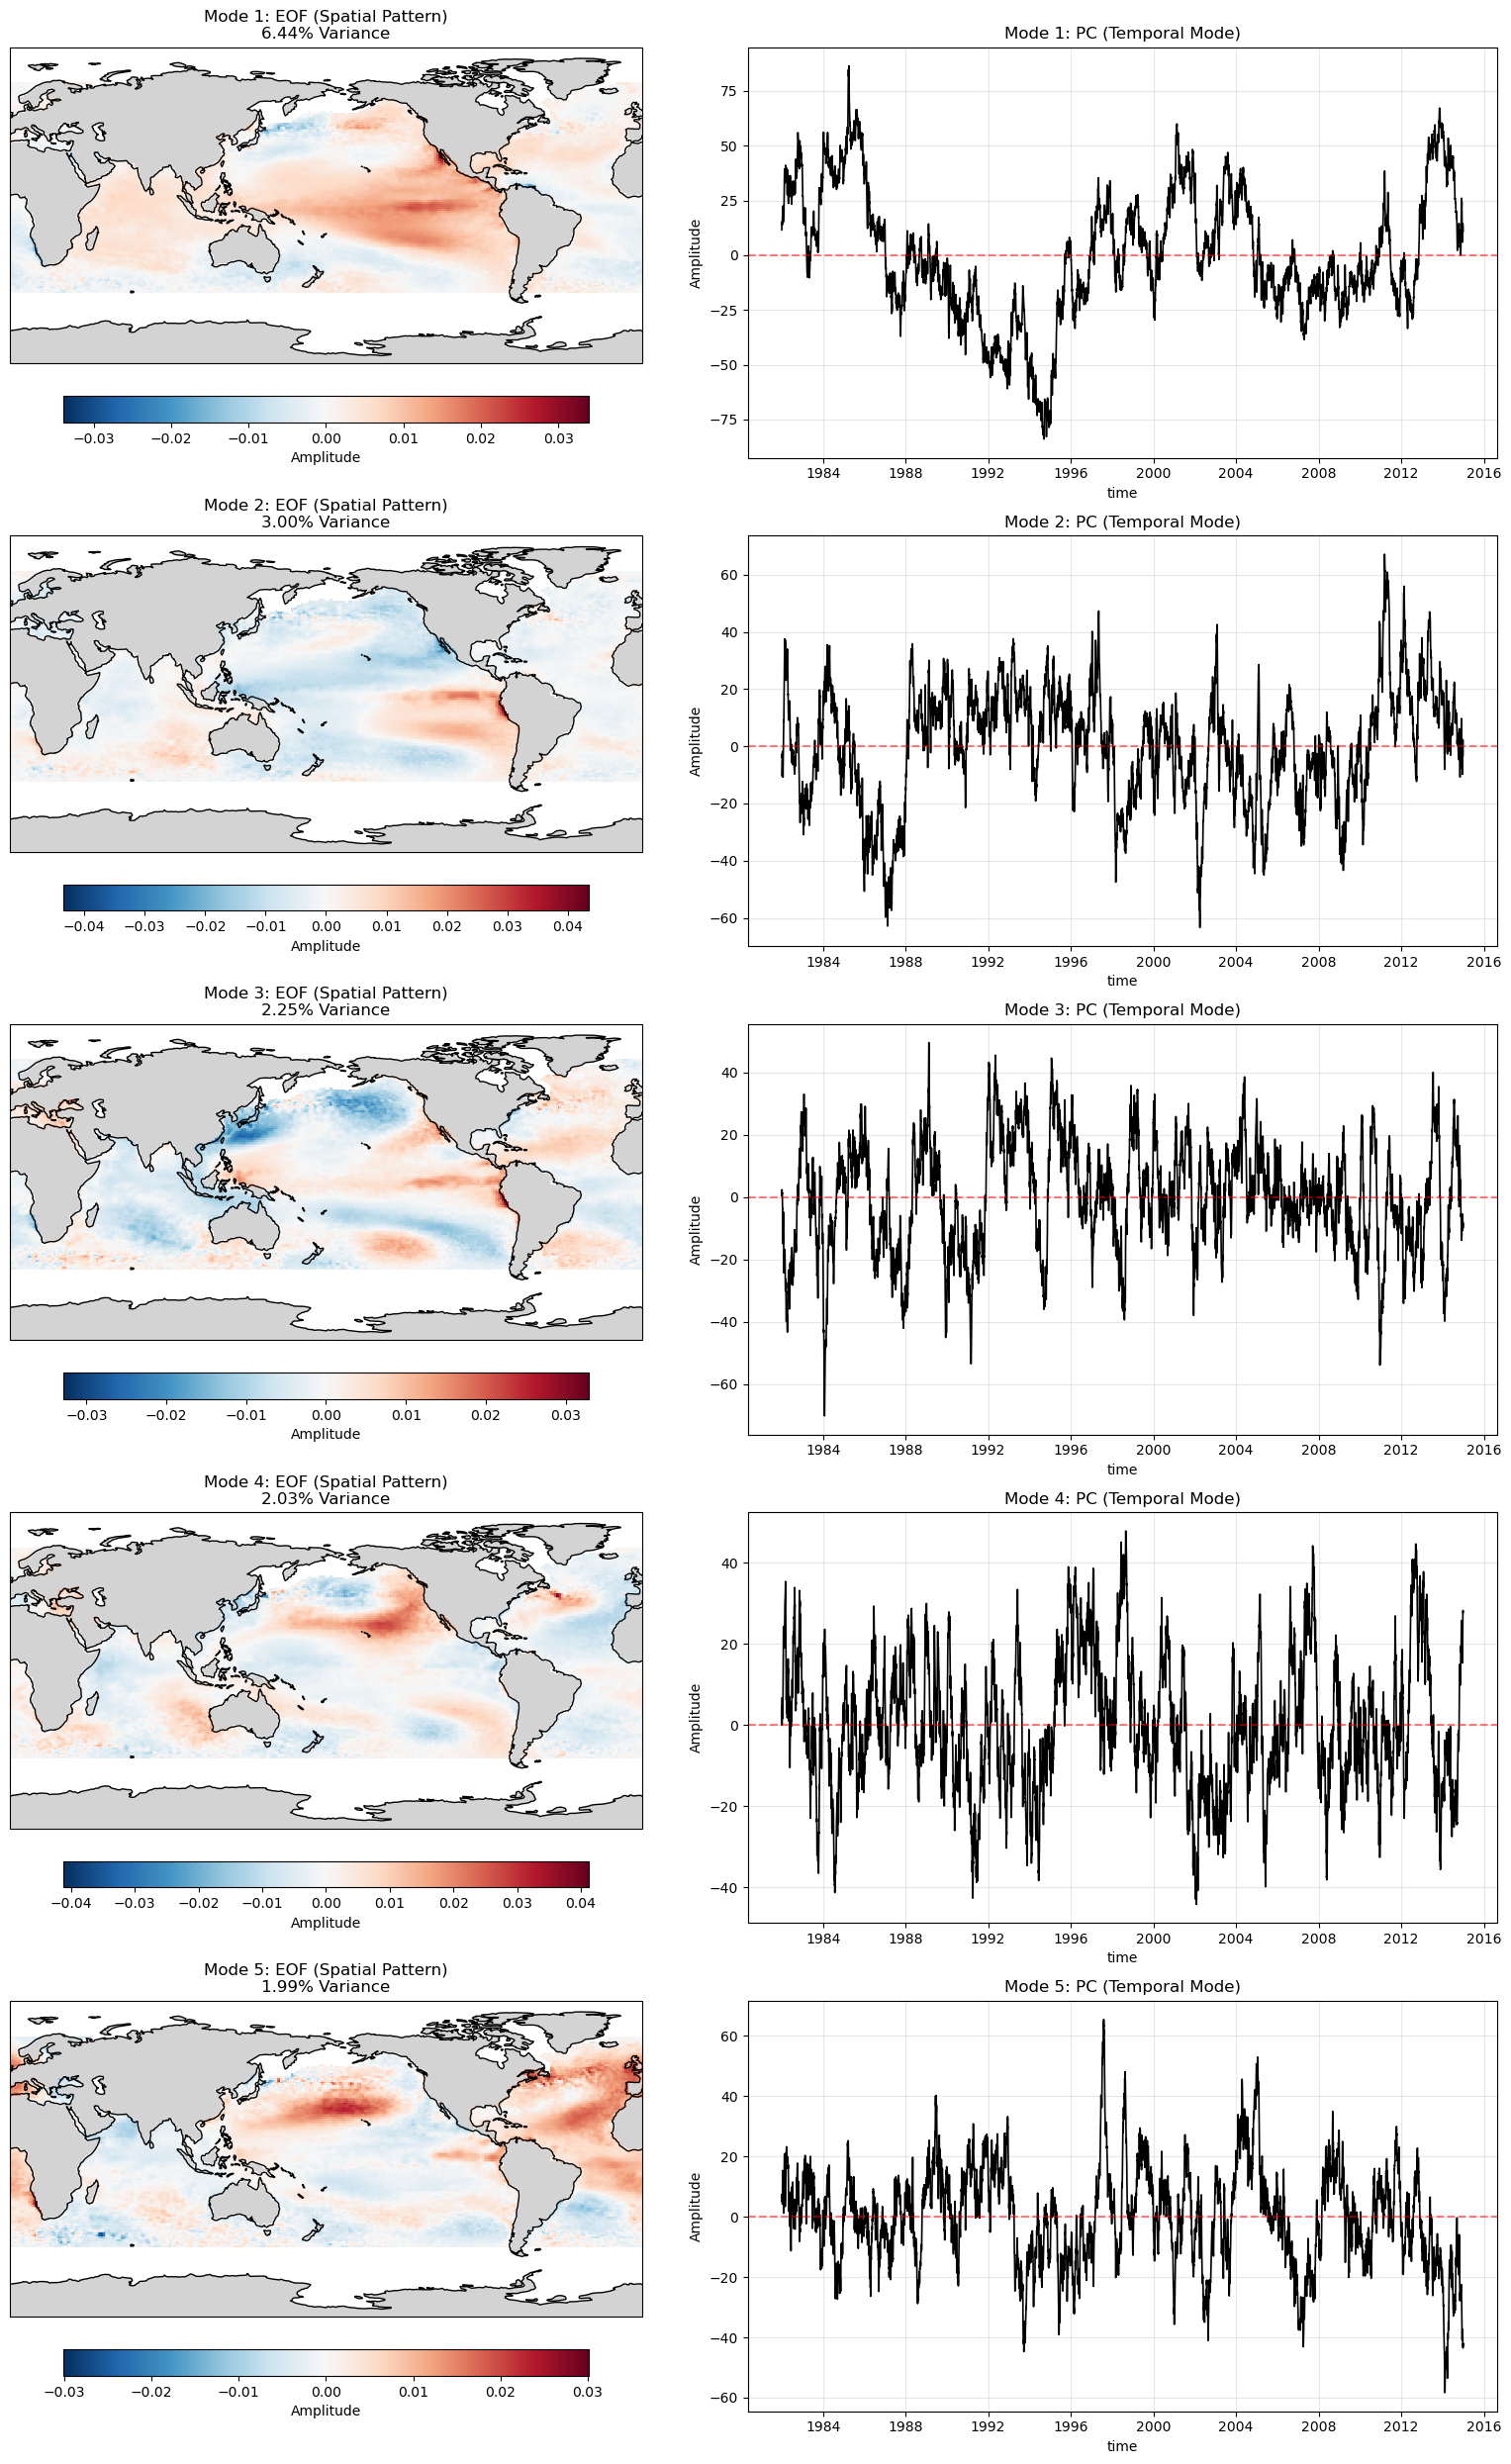

In [25]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cartopy.feature as cfeature

# 1. Get the results
eofs = model.components()
pcs = model.scores()
exp_var_i = model.explained_variance_ratio() * 100

# 2. Setup Figure
n_modes = 5
fig = plt.figure(figsize=(16, 5 * n_modes))

# Define the Pacific-centered projection
# 180 puts the International Date Line in the center
map_proj = ccrs.PlateCarree(central_longitude=180)
# Data transform stays as standard (0 central longitude)
data_trans = ccrs.PlateCarree()

for i in range(n_modes):
    mode_num = i + 1
    
    # --- EOF Map (Left Column) ---
    ax_map = fig.add_subplot(n_modes, 2, 2*i + 1, projection=map_proj)
    
    # Crucial: Force the map to show the whole world
    ax_map.set_global()
    
    # Plot data
    # transform=data_trans tells cartopy your lon/lat values are in standard coords
    p = eofs.sel(mode=mode_num).plot(
        ax=ax_map, 
        transform=data_trans, 
        cmap='RdBu_r',
        add_colorbar=False
    )
    
    # Add map features
    ax_map.coastlines()
    ax_map.add_feature(cfeature.LAND, facecolor='lightgray')
    
    # Add a horizontal colorbar below the map
    plt.colorbar(p, ax=ax_map, orientation='horizontal', label='Amplitude', pad=0.08, shrink=0.7)
    
    ax_map.set_title(f"Mode {mode_num}: EOF (Spatial Pattern)\n{exp_var_i.values[i]:.2f}% Variance")

    # --- PC Time Series (Right Column) ---
    ax_ts = fig.add_subplot(n_modes, 2, 2*i + 2)
    pcs.sel(mode=mode_num).plot(ax=ax_ts, color='black', lw=1.2)
    ax_ts.axhline(0, color='red', linestyle='--', alpha=0.5)
    ax_ts.set_title(f"Mode {mode_num}: PC (Temporal Mode)")
    ax_ts.set_ylabel("Amplitude")
    ax_ts.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
o_exx=o_ex.chunk(chunks={'time': 50, 'lat': -1, 'lon': -1}).isel(time=slice(365,1048))
o_exx

<xarray.DataArray 'extreme_events' (time: 683, lat: 480, lon: 1440)> Size: 472MB
dask.array<getitem, shape=(683, 480, 1440), dtype=bool, chunksize=(50, 480, 1440), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 5kB 1983-01-01T12:00:00 ... 1984-11-13T12:...
  * lat      (lat) float32 2kB -49.88 -49.62 -49.38 -49.12 ... 69.38 69.62 69.88
  * lon      (lon) float32 6kB -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9

In [10]:
%%time
from dask import persist
from dask_image.ndmeasure import label
extreme_events_ds=o_exx
data_bin=o_exx
neighbours = np.zeros((3, 3, 3))


neighbours[1, :, :] = 1  # All 8 neighbours, but ignore time


object_id_field, N_objects = label(
    data_bin,
    structure=neighbours,
    wrap_axes=(2,),  # Wrap in x-direction !
)

results = persist(object_id_field, N_objects)
object_id_field, N_objects = results

N_objects = N_objects.compute()

# Convert to DataArray with same coordinates as input
object_id_field = (
    xr.DataArray(
        object_id_field,
        coords=data_bin.coords,
        dims=data_bin.dims,
        attrs=data_bin.attrs,
    )
    .rename("ID_field")
    .astype(np.int32)
)



CPU times: user 17.8 s, sys: 6.65 s, total: 24.5 s
Wall time: 1min 36s


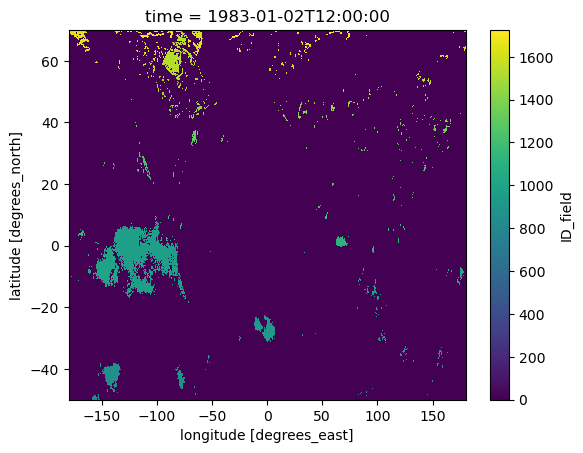

In [15]:
object_id_field.isel(time=1).plot()

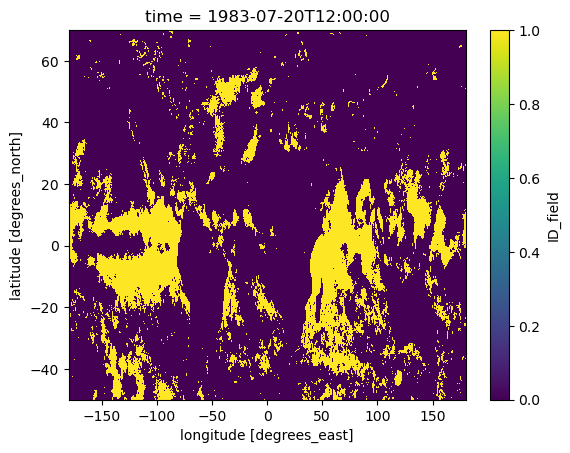

In [14]:
(object_id_field>1).isel(time=200).plot()

In [43]:

#Proper area thing using object_id_field:



# Calculate grid areas
R_earth = 6371.0  # km
resolution = 0.25  # deg

lat_r, lon_r, dlat, dlon = (
    np.radians(extreme_events_ds.lat),
    np.radians(extreme_events_ds.lon),
    np.radians(resolution),
    np.radians(resolution),
)
grid_area = (R_earth**2 * np.abs(np.sin(lat_r + dlat / 2) - np.sin(lat_r - dlat / 2)) * dlon).astype(np.float32)
     

def compute_areas_by_id(id_field, grid_area):
    """Compute area for each ID using efficient indexing"""
    # Broadcast grid_area to match id_field shape
    grid_broadcast = np.broadcast_to(grid_area[:, np.newaxis], id_field.shape)
    areas = np.zeros(len(unique_ids), dtype=np.float32)

    # Vectorised accumulation
    flat_ids = id_field.ravel()
    flat_grid = grid_broadcast.ravel()

    for idx, id_val in range(N_objects):
        areas[idx] = flat_grid[flat_ids == id_val].sum()

    return areas


areas = xr.apply_ufunc(
    compute_areas_by_id,
    object_id_field,
    grid_area,
    input_core_dims=[["lat", "lon"], ["lat"]],
    output_core_dims=[["ID"]],
    dask="parallelized",
    vectorize=True,
    output_dtypes=[np.float32],
)

areas = areas.compute()


dask.array<getitem, shape=(183, 480, 1440), dtype=int32, chunksize=(50, 480, 1440), chunktype=numpy.ndarray>